<Figure size 1800x500 with 0 Axes>

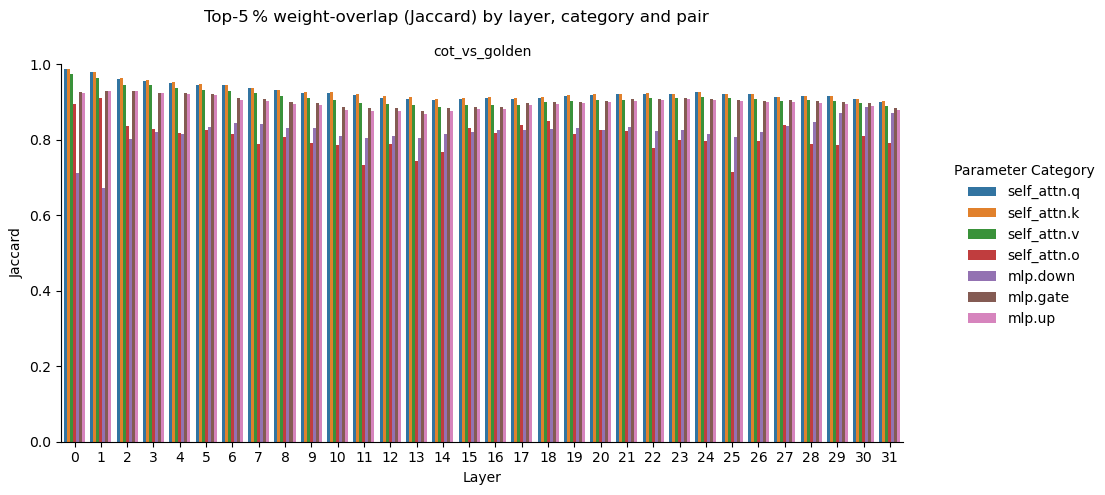


==== Mean Jaccard per category (averaged over layers) ====
         Pair    Category  Jaccard
cot_vs_golden    mlp.down 0.820437
cot_vs_golden    mlp.gate 0.903126
cot_vs_golden      mlp.up 0.898425
cot_vs_golden self_attn.k 0.928009
cot_vs_golden self_attn.o 0.807619
cot_vs_golden self_attn.q 0.926322
cot_vs_golden self_attn.v 0.912547

==== Overall mean Jaccard index: 0.8852 ====


In [2]:
#!/usr/bin/env python
"""
Compute the Jaccard overlap of the top‑k (default 5 %) absolute‑magnitude weights
between *any* pair drawn from three GSM8K weight‑only WANDe disentanglement runs:
    • CoT‑0‑shot (cot)
    • Direct (direct)
    • CoT‑0‑shot‑gold‑reason (golden)

For every transformer **layer** and **parameter category** (q/k/v/o projections and
MLP up/gate/down projections), the script
1. loads the corresponding weight tensors,
2. builds binary masks marking the top‑k entries,
3. computes the Jaccard index for each pair,
4. aggregates the results into a tidy DataFrame,
5. draws grouped bar charts (one facet per pair), and
6. prints the per‑pair, per‑category mean Jaccard across layers.

Run with a plain `python jaccard_three_dataset_analysis.py` after adjusting the
folder paths below if needed.  Matplotlib will pop up a window and the printed
means can be copy‑pasted into reports or notebooks.
"""

import os
import pickle
import re
import itertools
from collections import defaultdict

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# -----------------------------------------------------------------------------
# Configuration ────────────────────────────────────────────────────────────────
# -----------------------------------------------------------------------------

DATASETS = {
   "cot": {
        "dir": "../out/llama2-7b-chat-hf/unstructured/wanda_weightonly/GSM8K_cot0shot_120/wanda_score/GSM8K_cot0shot_120_weight_only_disentangle",
        "tag": "GSM8K_cot0shot_120",
    },

    "golden": {
        "dir": "../out/llama2-7b-chat-hf/unstructured/wanda_weightonly/GSM8K_cot0shot_goldreason/wanda_score/GSM8K_cot0shot_goldreason_weight_only_disentangle",
        "tag": "GSM8K_cot0shot_goldreason",
    },
}

# Map human‑readable category names (left) to the substrings contained in the
# Wanda pickle filenames (right).
CATEGORIES = {
    "self_attn.q": "q_proj",
    "self_attn.k": "k_proj",
    "self_attn.v": "v_proj",
    "self_attn.o": "o_proj",
    "mlp.down": "down_proj",
    "mlp.gate": "gate_proj",
    "mlp.up": "up_proj",
}

TOPK_RATIO = 0.05  # top‑5 % mask

# -----------------------------------------------------------------------------
# Helper utilities ─────────────────────────────────────────────────────────────
# -----------------------------------------------------------------------------

def load_tensor(path):
    """Load a Wanda .pkl file and return the underlying NumPy weight array."""
    with open(path, "rb") as fh:
        obj = pickle.load(fh)
    if isinstance(obj, dict):
        # Wanda score dumps sometimes wrap the tensor under a 'weight' key
        obj = obj.get("weight", next(iter(obj.values())))
    return obj.detach().cpu().numpy()


def topk_mask(tensor: np.ndarray, ratio: float = TOPK_RATIO) -> np.ndarray:
    """Return a bool mask with 1s at the top‑|ratio| absolute entries."""
    flat = np.abs(tensor).ravel()
    k = max(1, int(flat.size * ratio))
    thresh = np.partition(flat, -k)[-k]
    return (np.abs(tensor) >= thresh)


def jaccard(m1: np.ndarray, m2: np.ndarray) -> float:
    inter = np.logical_and(m1, m2).sum()
    union = np.logical_or(m1, m2).sum()
    return float(inter) / union if union else 0.0


# -----------------------------------------------------------------------------
# Core computation ─────────────────────────────────────────────────────────────
# -----------------------------------------------------------------------------

def collect_pairwise(pair: tuple[str, str]):
    """Compute Jaccard matrix for one dataset *pair* (e.g. ('cot','direct'))."""
    name_a, name_b = pair
    
    dir_a, tag_a = DATASETS[name_a].values()
    dir_b, tag_b = DATASETS[name_b].values()

    out = defaultdict(dict)  # out[layer][category] = jaccard value

    for fname in os.listdir(dir_a):
        if tag_a not in fname:
            continue

        fname_b = fname.replace(tag_a, tag_b)
        path_a, path_b = os.path.join(dir_a, fname), os.path.join(dir_b, fname_b)
        if not os.path.exists(path_b):
            continue  # skip mismatching layers / categories

        try:
            t_a = load_tensor(path_a)
            t_b = load_tensor(path_b)
        except Exception as exc:  # corrupt file, skip with a warning
            print(f"⚠️  Skipping {fname} → {fname_b}: {exc}")
            continue
        if not os.path.exists(path_b):
            print(f"❌ Missing file: {path_b}")
            continue
        m_a, m_b = topk_mask(t_a), topk_mask(t_b)
        jac = jaccard(m_a, m_b)

        # Determine layer and category from filename
        layer_match = re.search(r"layer_(\d+)", fname)
        if not layer_match:
            continue
        layer = int(layer_match.group(1))

        for cat_name, cat_key in CATEGORIES.items():
            if cat_key in fname:
                out[layer][cat_name] = jac
                break

    return out


# Aggregate across all three choose‑two pairs
pair_results = {}
for pair in itertools.combinations(DATASETS.keys(), 2):
    pair_name = f"{pair[0]}_vs_{pair[1]}"
    pair_results[pair_name] = collect_pairwise(pair)

# -----------------------------------------------------------------------------
# Tidy DataFrame for plotting / stats ─────────────────────────────────────────
# -----------------------------------------------------------------------------
rows = []
for pair_name, matrix in pair_results.items():
    for layer, cats in matrix.items():
        for cat in CATEGORIES.keys():
            rows.append({
                "Pair": pair_name,
                "Layer": layer,
                "Category": cat,
                "Jaccard": cats.get(cat, np.nan),
            })

df = pd.DataFrame(rows)

# -----------------------------------------------------------------------------
# Visualisation ────────────────────────────────────────────────────────────────
# -----------------------------------------------------------------------------
plt.figure(figsize=(18, 5))
cat_plot = sns.catplot(
    data=df,
    x="Layer",
    y="Jaccard",
    hue="Category",
    col="Pair",
    kind="bar",
    palette="tab10",
    height=5,
    aspect=1.6,
)
cat_plot.set_titles("{col_name}")
cat_plot.set(ylim=(0, 1))
cat_plot.fig.subplots_adjust(top=0.85)
cat_plot.fig.suptitle("Top‑5 % weight‑overlap (Jaccard) by layer, category and pair")
legend = cat_plot._legend
legend.set_title("Parameter Category")
legend.set_bbox_to_anchor((1.02, 0.5))  # move legend outside the plot
legend.set_loc("center left")
plt.tight_layout()
plt.show()

# -----------------------------------------------------------------------------
# Statistics ─────────────────────────────────────────────────────────────────--
# -----------------------------------------------------------------------------
print("\n==== Mean Jaccard per category (averaged over layers) ====")
mean_table = (
    df.groupby(["Pair", "Category"], as_index=False)["Jaccard"]
    .mean()
    .sort_values(["Pair", "Category"])
)
print(mean_table.to_string(index=False))

# total average
total_mean = df["Jaccard"].mean()
print(f"\n==== Overall mean Jaccard index: {total_mean:.4f} ====")


In [ ]:
#!/usr/bin/env python
"""
Compute the Jaccard overlap of the top‑k (default 5 %) absolute‑magnitude weights
between *any* pair drawn from three GSM8K weight‑only WANDe disentanglement runs:
    • CoT‑0‑shot (cot)
    • Direct (direct)
    • CoT‑0‑shot‑gold‑reason (golden)

For every transformer **layer** and **parameter category** (q/k/v/o projections and
MLP up/gate/down projections), the script
1. loads the corresponding weight tensors,
2. builds binary masks marking the top‑k entries,
3. computes the Jaccard index for each pair,
4. aggregates the results into a tidy DataFrame,
5. draws grouped bar charts (one facet per pair), and
6. prints the per‑pair, per‑category mean Jaccard across layers.

Run with a plain `python jaccard_three_dataset_analysis.py` after adjusting the
folder paths below if needed.  Matplotlib will pop up a window and the printed
means can be copy‑pasted into reports or notebooks.
"""

import os
import pickle
import re
import itertools
from collections import defaultdict

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# -----------------------------------------------------------------------------
# Configuration ────────────────────────────────────────────────────────────────
# -----------------------------------------------------------------------------

DATASETS = {
    
    "direct": {
        "dir": "../out/llama2-7b-chat-hf/unstructured/wanda_weightonly/GSM8K_direct_120/wanda_score/GSM8K_direct_120_weight_only_disentangle",
        "tag": "GSM8K_direct_120",
    },
    "golden": {
        "dir": "../out/llama2-7b-chat-hf/unstructured/wanda_weightonly/GSM8K_cot0shot_goldreason/wanda_score/GSM8K_cot0shot_goldreason_weight_only_disentangle",
        "tag": "GSM8K_cot0shot_goldreason",
    },
}

# Map human‑readable category names (left) to the substrings contained in the
# Wanda pickle filenames (right).
CATEGORIES = {
    "self_attn.q": "q_proj",
    "self_attn.k": "k_proj",
    "self_attn.v": "v_proj",
    "self_attn.o": "o_proj",
    "mlp.down": "down_proj",
    "mlp.gate": "gate_proj",
    "mlp.up": "up_proj",
}

TOPK_RATIO = 0.05  # top‑5 % mask

# -----------------------------------------------------------------------------
# Helper utilities ─────────────────────────────────────────────────────────────
# -----------------------------------------------------------------------------

def load_tensor(path):
    """Load a Wanda .pkl file and return the underlying NumPy weight array."""
    with open(path, "rb") as fh:
        obj = pickle.load(fh)
    if isinstance(obj, dict):
        # Wanda score dumps sometimes wrap the tensor under a 'weight' key
        obj = obj.get("weight", next(iter(obj.values())))
    return obj.detach().cpu().numpy()


def topk_mask(tensor: np.ndarray, ratio: float = TOPK_RATIO) -> np.ndarray:
    """Return a bool mask with 1s at the top‑|ratio| absolute entries."""
    flat = np.abs(tensor).ravel()
    k = max(1, int(flat.size * ratio))
    thresh = np.partition(flat, -k)[-k]
    return (np.abs(tensor) >= thresh)


def jaccard(m1: np.ndarray, m2: np.ndarray) -> float:
    inter = np.logical_and(m1, m2).sum()
    union = np.logical_or(m1, m2).sum()
    return float(inter) / union if union else 0.0


# -----------------------------------------------------------------------------
# Core computation ─────────────────────────────────────────────────────────────
# -----------------------------------------------------------------------------

def collect_pairwise(pair: tuple[str, str]):
    """Compute Jaccard matrix for one dataset *pair* (e.g. ('cot','direct'))."""
    name_a, name_b = pair
    
    dir_a, tag_a = DATASETS[name_a].values()
    dir_b, tag_b = DATASETS[name_b].values()

    out = defaultdict(dict)  # out[layer][category] = jaccard value

    for fname in os.listdir(dir_a):
        if tag_a not in fname:
            continue

        fname_b = fname.replace(tag_a, tag_b)
        path_a, path_b = os.path.join(dir_a, fname), os.path.join(dir_b, fname_b)
        if not os.path.exists(path_b):
            continue  # skip mismatching layers / categories

        try:
            t_a = load_tensor(path_a)
            t_b = load_tensor(path_b)
        except Exception as exc:  # corrupt file, skip with a warning
            print(f"⚠️  Skipping {fname} → {fname_b}: {exc}")
            continue
        if not os.path.exists(path_b):
            print(f"❌ Missing file: {path_b}")
            continue
        m_a, m_b = topk_mask(t_a), topk_mask(t_b)
        jac = jaccard(m_a, m_b)

        # Determine layer and category from filename
        layer_match = re.search(r"layer_(\d+)", fname)
        if not layer_match:
            continue
        layer = int(layer_match.group(1))

        for cat_name, cat_key in CATEGORIES.items():
            if cat_key in fname:
                out[layer][cat_name] = jac
                break

    return out


# Aggregate across all three choose‑two pairs
pair_results = {}
for pair in itertools.combinations(DATASETS.keys(), 2):
    pair_name = f"{pair[0]}_vs_{pair[1]}"
    pair_results[pair_name] = collect_pairwise(pair)

# -----------------------------------------------------------------------------
# Tidy DataFrame for plotting / stats ─────────────────────────────────────────
# -----------------------------------------------------------------------------
rows = []
for pair_name, matrix in pair_results.items():
    for layer, cats in matrix.items():
        for cat in CATEGORIES.keys():
            rows.append({
                "Pair": pair_name,
                "Layer": layer,
                "Category": cat,
                "Jaccard": cats.get(cat, np.nan),
            })

df = pd.DataFrame(rows)

# -----------------------------------------------------------------------------
# Visualisation ────────────────────────────────────────────────────────────────
# -----------------------------------------------------------------------------
plt.figure(figsize=(18, 5))
cat_plot = sns.catplot(
    data=df,
    x="Layer",
    y="Jaccard",
    hue="Category",
    col="Pair",
    kind="bar",
    palette="tab10",
    height=5,
    aspect=1.6,
)
cat_plot.set_titles("{col_name}")
cat_plot.set(ylim=(0, 1))
cat_plot.fig.subplots_adjust(top=0.85)
cat_plot.fig.suptitle("Top‑5 % weight‑overlap (Jaccard) by layer, category and pair")
legend = cat_plot._legend
legend.set_title("Parameter Category")
legend.set_bbox_to_anchor((1.02, 0.5))  # move legend outside the plot
legend.set_loc("center left")
plt.tight_layout()
plt.show()

# -----------------------------------------------------------------------------
# Statistics ─────────────────────────────────────────────────────────────────--
# -----------------------------------------------------------------------------
print("\n==== Mean Jaccard per category (averaged over layers) ====")
mean_table = (
    df.groupby(["Pair", "Category"], as_index=False)["Jaccard"]
    .mean()
    .sort_values(["Pair", "Category"])
)
print(mean_table.to_string(index=False))

# total average
total_mean = df["Jaccard"].mean()
print(f"\n==== Overall mean Jaccard index: {total_mean:.4f} ====")


In [4]:
os.listdir(wanda_dir)

['GSM8K_cot0shot_weight_only_disentangle']

In [ ]:
import torch
import pickle
import numpy as np

def load_tensor(filepath):
    with open(filepath, "rb") as f:
        data = pickle.load(f)
    if isinstance(data, dict):
        data = data["weight"] if "weight" in data else list(data.values())[0]
    return data.detach().cpu().numpy()

def get_topk_mask(tensor, topk_ratio=0.05):
    flat = np.abs(tensor.flatten())
    k = int(len(flat) * topk_ratio)
    if k == 0:
        raise ValueError("Tensor too small for top-k calculation.")
    threshold = np.partition(flat, -k)[-k]  # kth largest absolute value
    return (np.abs(tensor) >= threshold).astype(int)

def jaccard_index(mask1, mask2):
    intersection = np.logical_and(mask1, mask2).sum()
    union = np.logical_or(mask1, mask2).sum()
    return intersection / union if union != 0 else 0.0

# 文件路径
wanda_path = "/common/users/sl2148/Public/yang_ouyang/alignment-attribution-code/scripts/out/llama2-7b-chat-hf/unstructured/wanda_weightonly/GSM8K_cot0shot/wanda_score/GSM8K_cot0shot_weight_only_disentangle/W_metric_layer_0_name_mlp.down_proj_GSM8K_cot0shot_weight_only_disentangle.pkl"
direct_path = "/common/users/sl2148/Public/yang_ouyang/alignment-attribution-code/scripts/out/llama2-7b-chat-hf/unstructured/wanda_weightonly/GSM8K_direct/wanda_score/GSM8K_direct_weight_only_disentangle/W_metric_layer_0_name_mlp.down_proj_GSM8K_direct_weight_only_disentangle.pkl"

# 加载权重
wanda_tensor = load_tensor(wanda_path)
direct_tensor = load_tensor(direct_path)

# 计算 Top 5% 的位置掩码
wanda_mask = get_topk_mask(wanda_tensor, topk_ratio=0.05)
direct_mask = get_topk_mask(direct_tensor, topk_ratio=0.05)

# compute Jaccard Index
jaccard = jaccard_index(wanda_mask, direct_mask)
print("Top 5% Jaccard Index:", jaccard)


Top 5% Jaccard Index: 0.5049970827264024


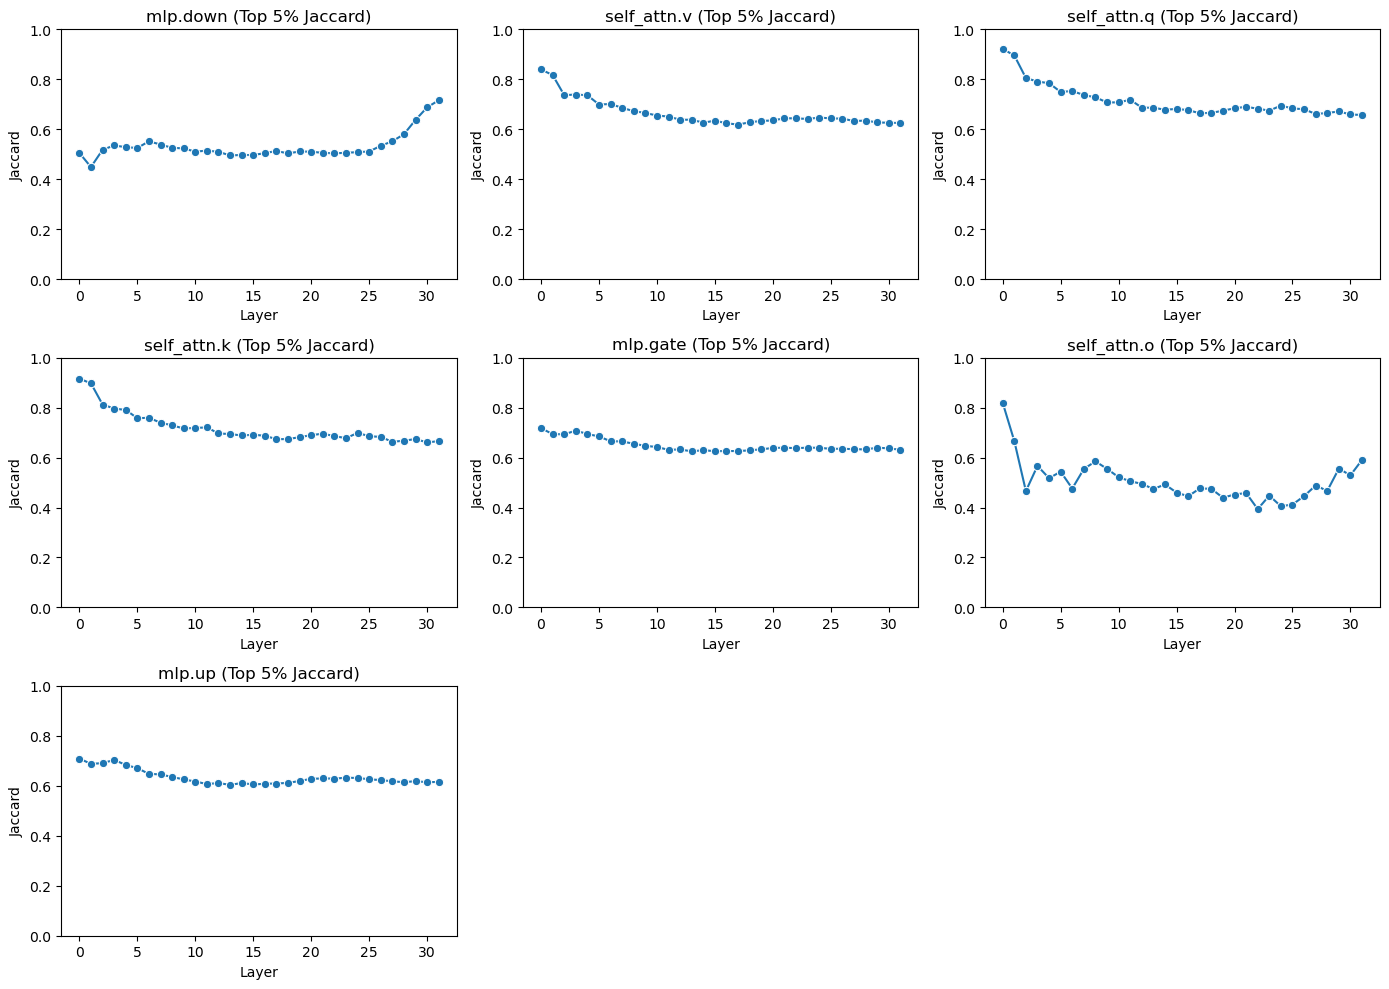

In [ ]:
import os
import pickle
import numpy as np
import re
import torch
import matplotlib.pyplot as plt
import seaborn as sns
from collections import defaultdict

# 设置路径
cot_dir = "../out/llama2-7b-chat-hf/unstructured/wanda_weightonly/GSM8K_cot0shot_120/wanda_score/GSM8K_cot0shot_120_weight_only_disentangle"

direct_dir = "../out/llama2-7b-chat-hf/unstructured/wanda_weightonly/GSM8K_direct_120/wanda_score/GSM8K_direct_120_weight_only_disentangle"
golden_reason_dir = "../out/llama2-7b-chat-hf/unstructured/wanda_weightonly/GSM8K_cot0shot_goldreason/wanda_score/GSM8K_cot0shot_goldreason_weight_only_disentangle"

cot_tag = "GSM8K_cot0shot"
direct_tag = "GSM8K_direct"
golden_reason_tag = "GSM8K_cot0shot_goldreason"

# 分类对应关系
categories = {
    "self_attn.q": "q_proj",
    "self_attn.k": "k_proj",
    "self_attn.v": "v_proj",
    "self_attn.o": "o_proj",
    "mlp.down": "down_proj",
    "mlp.gate": "gate_proj",
    "mlp.up": "up_proj"
}

# 加载 tensor 并转换为 top-k 掩码
def load_tensor(filepath):
    with open(filepath, "rb") as f:
        data = pickle.load(f)
    if isinstance(data, dict):
        data = data["weight"] if "weight" in data else list(data.values())[0]
    return data.detach().cpu().numpy()

def get_topk_mask(tensor, topk_ratio=0.05):
    flat = np.abs(tensor.flatten())
    k = int(len(flat) * topk_ratio)
    threshold = np.partition(flat, -k)[-k]
    return (np.abs(tensor) >= threshold).astype(int)

def jaccard_index(mask1, mask2):
    intersection = np.logical_and(mask1, mask2).sum()
    union = np.logical_or(mask1, mask2).sum()
    return intersection / union if union != 0 else 0.0

# 保存每类的 jaccard 指数结果
jaccard_by_category = defaultdict(list)

# 遍历 Wanda 文件
wanda_files = [f for f in os.listdir(wanda_dir) if cot_tag in f]
for wanda_file in wanda_files:
    direct_file = wanda_file.replace(cot_tag, direct_tag)
    wanda_path = os.path.join(wanda_dir, wanda_file)
    direct_path = os.path.join(direct_dir, direct_file)

    if not os.path.exists(direct_path):
        continue

    try:
        wanda_tensor = load_tensor(wanda_path)
        direct_tensor = load_tensor(direct_path)

        wanda_mask = get_topk_mask(wanda_tensor, topk_ratio=0.05)
        direct_mask = get_topk_mask(direct_tensor, topk_ratio=0.05)

        jaccard = jaccard_index(wanda_mask, direct_mask)

        # 分类模块 + 层号
        for cat_key, cat_val in categories.items():
            if cat_val in wanda_file:
                match = re.search(r"layer_(\d+)", wanda_file)
                layer = int(match.group(1)) if match else -1
                jaccard_by_category[cat_key].append((layer, jaccard))
                break
    except Exception as e:
        print(f"Skipping {wanda_file} due to error: {e}")

# sort and plot
plt.figure(figsize=(14, 10))
for i, (cat, values) in enumerate(jaccard_by_category.items(), 1):
    values = sorted(values, key=lambda x: x[0])
    layers, jaccards = zip(*values)
    plt.subplot(3, 3, i)
    sns.lineplot(x=layers, y=jaccards, marker='o')
    plt.title(f"{cat} (Top 5% Jaccard)")
    plt.xlabel("Layer")
    plt.ylabel("Jaccard")
    plt.ylim(0, 1)

plt.tight_layout()
plt.show()


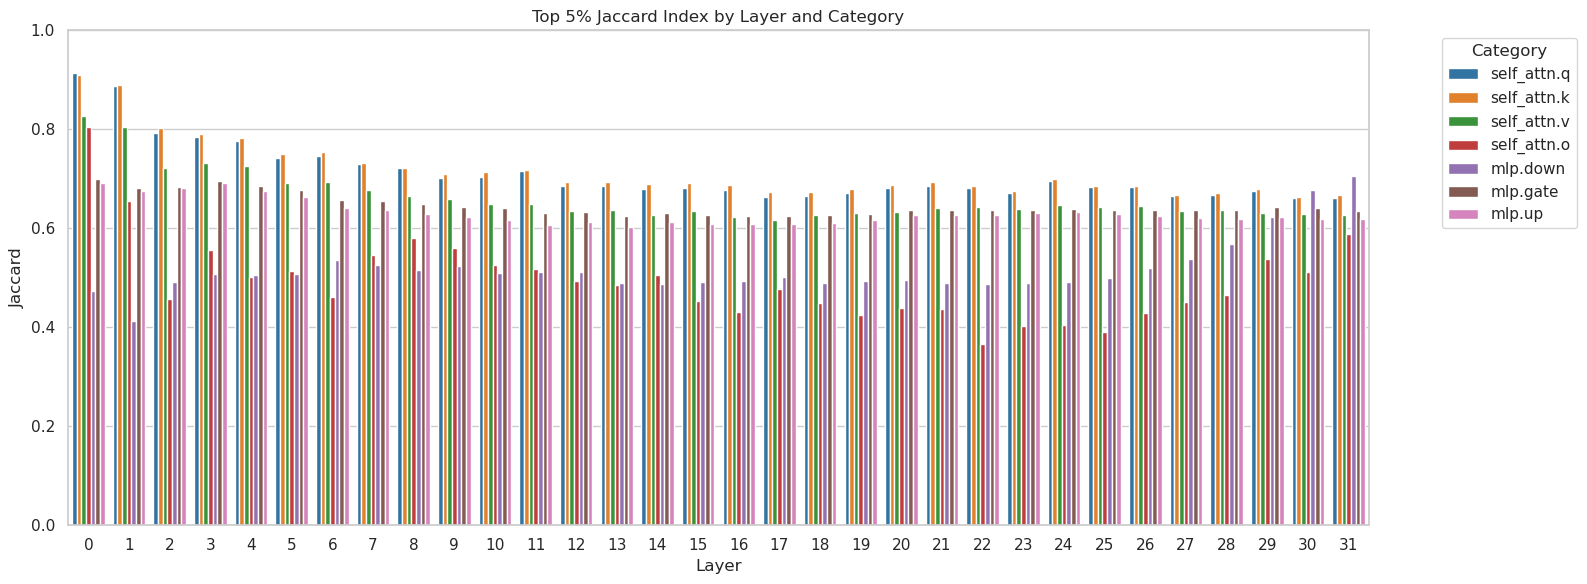

<bound method Series.reset_index of Category
mlp.down       0.517671
mlp.gate       0.646100
mlp.up         0.631449
self_attn.k    0.716029
self_attn.o    0.494541
self_attn.q    0.710439
self_attn.v    0.661828
Name: Jaccard, dtype: float64>


In [6]:
import os
import pickle
import numpy as np
import re
import torch
import matplotlib.pyplot as plt
import seaborn as sns
from collections import defaultdict

# 设置路径
cot_dir = "../out/llama2-7b-chat-hf/unstructured/wanda_weightonly/GSM8K_cot0shot_120/wanda_score/GSM8K_cot0shot_120_weight_only_disentangle"
direct_dir = "../out/llama2-7b-chat-hf/unstructured/wanda_weightonly/GSM8K_direct_120/wanda_score/GSM8K_direct_120_weight_only_disentangle"
wanda_dir = cot_dir  # fix missing var
wanda_tag = "GSM8K_cot0shot"
direct_tag = "GSM8K_direct"

# 分类对应关系
categories = {
    "self_attn.q": "q_proj",
    "self_attn.k": "k_proj",
    "self_attn.v": "v_proj",
    "self_attn.o": "o_proj",
    "mlp.down": "down_proj",
    "mlp.gate": "gate_proj",
    "mlp.up": "up_proj"
}

# 加载 tensor 并转换为 top-k 掩码
def load_tensor(filepath):
    with open(filepath, "rb") as f:
        data = pickle.load(f)
    if isinstance(data, dict):
        data = data["weight"] if "weight" in data else list(data.values())[0]
    return data.detach().cpu().numpy()

def get_topk_mask(tensor, topk_ratio=0.05):
    flat = np.abs(tensor.flatten())
    k = int(len(flat) * topk_ratio)
    threshold = np.partition(flat, -k)[-k]
    return (np.abs(tensor) >= threshold).astype(int)

def jaccard_index(mask1, mask2):
    intersection = np.logical_and(mask1, mask2).sum()
    union = np.logical_or(mask1, mask2).sum()
    return intersection / union if union != 0 else 0.0

# 保存 jaccard[layer][category] = score
jaccard_matrix = defaultdict(dict)

wanda_files = [f for f in os.listdir(wanda_dir) if wanda_tag in f]
for wanda_file in wanda_files:
    direct_file = wanda_file.replace(wanda_tag, direct_tag)
    wanda_path = os.path.join(wanda_dir, wanda_file)
    direct_path = os.path.join(direct_dir, direct_file)

    if not os.path.exists(direct_path):
        continue

    try:
        wanda_tensor = load_tensor(wanda_path)
        direct_tensor = load_tensor(direct_path)

        wanda_mask = get_topk_mask(wanda_tensor, topk_ratio=0.05)
        direct_mask = get_topk_mask(direct_tensor, topk_ratio=0.05)

        jaccard = jaccard_index(wanda_mask, direct_mask)

        # 分类模块 + 层号
        for cat_key, cat_val in categories.items():
            if cat_val in wanda_file:
                match = re.search(r"layer_(\d+)", wanda_file)
                if match:
                    layer = int(match.group(1))
                    jaccard_matrix[layer][cat_key] = jaccard
                break
    except Exception as e:
        print(f"Skipping {wanda_file} due to error: {e}")

# 组织数据为 pandas-friendly 格式
import pandas as pd

rows = []
for layer in sorted(jaccard_matrix.keys()):
    for cat in categories.keys():
        rows.append({
            "Layer": layer,
            "Category": cat,
            "Jaccard": jaccard_matrix[layer].get(cat, np.nan)
        })

df = pd.DataFrame(rows)

# 画 grouped bar chart
plt.figure(figsize=(16, 6))
sns.barplot(data=df, x="Layer", y="Jaccard", hue="Category", palette="tab10")
plt.title("Top 5% Jaccard Index by Layer and Category")
plt.ylim(0, 1)
plt.legend(title="Category", bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()

# 给出layer平均值关于不同category的jaccard index
mean_jaccard = df.groupby("Category")["Jaccard"].mean().reset_index
print(mean_jaccard)


In [7]:
#!/usr/bin/env python
"""
Compute Jaccard overlap of top‑k (default 5 %) absolute‑magnitude weights between
three GSM8K WANDe weight‑only disentanglement runs (CoT‑0‑shot, Direct, CoT‑0‑shot‑gold‑reason).

Why this revision?  A few users reported **only one Pair facet** was being rendered.
Root causes:
  1.  Path construction hinged on a simple `str.replace(tag_a, tag_b)`; if any
      file in *dir_a* lacked the precise `tag_a` substring, its counterpart in
      *dir_b* would never be found → empty result for that Pair.
  2.  Dict unpacking via `dir_a, tag_a = DATASETS[name_a].values()` relied on
      insertion order, which could bite if you ever reorder keys.

Fixes & improvements here:
  • explicit `dir = DATASETS[pair]['dir']` and `tag = DATASETS[pair]['tag']`
  • more robust filename matching: we derive `(layer, category)` keys from the
    regex itself, then look those keys up in *both* directories instead of
    string‑replacement guessing.
  • progress / sanity prints so you immediately see how many matches each Pair
    produced.
  • optional `--debug` flag to spit out every attempted filename mapping.
"""
import os
import re
import pickle
import argparse
from pathlib import Path
from collections import defaultdict
import itertools

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# -----------------------------------------------------------------------------
# Configuration ────────────────────────────────────────────────────────────────
# -----------------------------------------------------------------------------

DATASETS = {
    "cot": {
        "dir": "../out/llama2-7b-chat-hf/unstructured/wanda_weightonly/GSM8K_cot0shot_120/wanda_score/GSM8K_cot0shot_120_weight_only_disentangle",
        "tag": "GSM8K_cot0shot",
    },
    "direct": {
        "dir": "../out/llama2-7b-chat-hf/unstructured/wanda_weightonly/GSM8K_direct_120/wanda_score/GSM8K_direct_120_weight_only_disentangle",
        "tag": "GSM8K_direct",
    },
    "golden": {
        "dir": "../out/llama2-7b-chat-hf/unstructured/wanda_weightonly/GSM8K_cot0shot_goldreason/wanda_score/GSM8K_cot0shot_goldreason_weight_only_disentangle",
        "tag": "GSM8K_cot0shot_goldreason",
    },
}

# layer / category regex helpers ------------------------------------------------
CATEGORIES = {
    "self_attn.q": "q_proj",
    "self_attn.k": "k_proj",
    "self_attn.v": "v_proj",
    "self_attn.o": "o_proj",
    "mlp.down": "down_proj",
    "mlp.gate": "gate_proj",
    "mlp.up": "up_proj",
}

LAYER_RE = re.compile(r"layer_(\d+)")

TOPK_RATIO = 0.05  # top‑5 % mask

# -----------------------------------------------------------------------------
# Helpers ─────────────────────────────────────────────────────────────────────-
# -----------------------------------------------------------------------------

def load_tensor(path: Path):
    """Load pickle & return np.ndarray."""
    with open(path, "rb") as fh:
        obj = pickle.load(fh)
    if isinstance(obj, dict):
        obj = obj.get("weight", next(iter(obj.values())))
    return obj.detach().cpu().numpy()


def topk_mask(arr: np.ndarray, ratio: float = TOPK_RATIO):
    flat = np.abs(arr).ravel()
    k = max(1, int(flat.size * ratio))
    thresh = np.partition(flat, -k)[-k]
    return np.abs(arr) >= thresh


def jaccard(m1: np.ndarray, m2: np.ndarray):
    inter = np.logical_and(m1, m2).sum()
    union = np.logical_or(m1, m2).sum()
    return float(inter) / union if union else np.nan


# -----------------------------------------------------------------------------
# Index every directory by (layer, category) → filepath ------------------------
# -----------------------------------------------------------------------------

def index_directory(root: str, tag: str):
    """Return a dict keyed by (layer, category) giving absolute filepaths."""
    idx: dict[tuple[int, str], str] = {}
    for fname in os.listdir(root):
        if tag not in fname:
            continue  # skip other tasks / checkpoints
        layer_m = LAYER_RE.search(fname)
        if not layer_m:
            continue
        layer = int(layer_m.group(1))
        for cat_name, cat_key in CATEGORIES.items():
            if cat_key in fname:
                idx[(layer, cat_name)] = os.path.join(root, fname)
                break
    return idx


# -----------------------------------------------------------------------------
# Build per‑dataset indices first (IO once) ------------------------------------
# -----------------------------------------------------------------------------
print("Indexing datasets …")
DATA_IDX = {
    name: index_directory(cfg["dir"], cfg["tag"]) for name, cfg in DATASETS.items()
}
for name, m in DATA_IDX.items():
    print(f"  {name:7s}: {len(m):4d} files indexed")

# -----------------------------------------------------------------------------
# Pairwise Jaccard calculation --------------------------------------------------
# -----------------------------------------------------------------------------

def pairwise_jaccard(a: str, b: str, debug: bool = False):
    """Return dict[layer][category] = Jaccard for pair (a, b)."""
    idx_a, idx_b = DATA_IDX[a], DATA_IDX[b]
    shared_keys = idx_a.keys() & idx_b.keys()
    if debug:
        print(f"  → {a} vs {b}: {len(shared_keys)} shared (layer,cat) combos")
    out: dict[int, dict[str, float]] = defaultdict(dict)
    for key in shared_keys:
        layer, cat = key
        try:
            t_a = load_tensor(idx_a[key])
            t_b = load_tensor(idx_b[key])
        except Exception as e:
            if debug:
                print(f"    ⚠️  Skipping {key}: {e}")
            continue
        out[layer][cat] = jaccard(topk_mask(t_a), topk_mask(t_b))
    return out

# -----------------------------------------------------------------------------
# CLI --------------------------------------------------------------------------
# -----------------------------------------------------------------------------
parser = argparse.ArgumentParser()
parser.add_argument("--debug", action="store_true", help="Verbose progress prints")
parser.add_argument("--save_fig", help="Optional path to save the PDF/PNG figure")
args = parser.parse_args()

# -----------------------------------------------------------------------------
# Compute all three choose‑two pairs ------------------------------------------
# -----------------------------------------------------------------------------
PAIR_RESULTS = {}
for pa, pb in itertools.combinations(DATASETS.keys(), 2):
    name = f"{pa}_vs_{pb}"
    PAIR_RESULTS[name] = pairwise_jaccard(pa, pb, debug=args.debug)

# Warn if any pair came back empty
for name, mat in PAIR_RESULTS.items():
    if not mat:
        print(f"⚠️  Pair {name} produced 0 matches – check your tags / filenames!")

# -----------------------------------------------------------------------------
# Tidy DataFrame ---------------------------------------------------------------
# -----------------------------------------------------------------------------
rows = []
for pair, mat in PAIR_RESULTS.items():
    for layer, cats in mat.items():
        for cat in CATEGORIES.keys():
            rows.append({
                "Pair": pair,
                "Layer": layer,
                "Category": cat,
                "Jaccard": cats.get(cat, np.nan),
            })

df = pd.DataFrame(rows)

if df.empty:
    raise SystemExit("No pair had overlapping files – exiting.")

# -----------------------------------------------------------------------------
# Plot -------------------------------------------------------------------------
# -----------------------------------------------------------------------------
print("Plotting …")
plt.figure(figsize=(18, 5))
g = sns.catplot(
    data=df,
    x="Layer",
    y="Jaccard",
    hue="Category",
    col="Pair",
    kind="bar",
    palette="tab10",
    height=5,
    aspect=1.6,
)
g.set_titles("{col_name}")
g.set(ylim=(0, 1))
g.fig.subplots_adjust(top=0.85, right=0.8)
# Legend outside
legend = g._legend
legend.set_title("Category")
legend.set_bbox_to_anchor((1.02, 0.5))
legend.set_loc("center left")
plt.tight_layout()
if args.save_fig:
    g.savefig(args.save_fig)
plt.show()

# -----------------------------------------------------------------------------
# Stats ------------------------------------------------------------------------
# -----------------------------------------------------------------------------
print("\n==== Mean Jaccard per category (averaged over layers) ====")
mean_tbl = (
    df.groupby(["Pair", "Category"], as_index=False)["Jaccard"].mean()
      .sort_values(["Pair", "Category"])
)
print(mean_tbl.to_string(index=False))
print(f"\n==== Overall mean Jaccard: {df['Jaccard'].mean():.4f} ====")


Indexing datasets …
  cot    :  224 files indexed
  direct :  224 files indexed
  golden :  224 files indexed


usage: ipykernel_launcher.py [-h] [--debug] [--save_fig SAVE_FIG]
ipykernel_launcher.py: error: unrecognized arguments: --f=/run/user/92109/jupyter/runtime/kernel-v3bda50c11de23e229d9fe5b98c54a01b2e5d5f870.json


SystemExit: 2

/common/home/sl2148/anaconda3/envs/prune_llm/lib/python3.9/site-packages/IPython/core/interactiveshell.py:3556: UserWarning: To exit: use 'exit', 'quit', or Ctrl-D.
  warn("To exit: use 'exit', 'quit', or Ctrl-D.", stacklevel=1)


In [4]:
df

,Pair,Layer,Category,Jaccard
0,cot_vs_direct,30,self_attn.o,0.510769
1,cot_vs_direct,21,self_attn.q,0.686328
2,cot_vs_direct,25,self_attn.q,0.683844
3,cot_vs_direct,16,mlp.up,0.608058
4,cot_vs_direct,1,mlp.gate,0.680832
...,...,...,...,...
219,cot_vs_direct,8,mlp.gate,0.649058
220,cot_vs_direct,18,mlp.gate,0.627591
221,cot_vs_direct,25,mlp.down,0.498596
222,cot_vs_direct,17,self_attn.q,0.663189


In [ ]:

# 给出layer平均值关于不同category的jaccard index
mean_jaccard = df.groupby("Category")["Jaccard"].mean().reset_index
print(mean_jaccard)